<a href="https://colab.research.google.com/github/hye0-n0/KRX_stock_prediction/blob/main/%5B0711%5DMonte_Carlo_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 라이브러리 다운로드
!pip install finance-datareader #주식 관련 라이브러리
!pip install PublicDataReader #한국 경제 통계 라이브러리

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.1 MB/s eta 0:00:00


In [ ]:
import random
import os
import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import repeat
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, RNN, Dropout, Flatten
from keras.optimizers import SGD
from sklearn.impute import SimpleImputer
from joblib import Parallel, delayed
from scipy import stats



import warnings
warnings.filterwarnings("ignore")

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

## DataLoad

공유드라이브는 mounting이 힘들기 때문에 </br>공유함에 있는 데이터 파일 open의 shortcut을 nyDrive에 만들면 됩니다

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/open/train.csv')
df

,일자,종목코드,종목명,거래량,시가,고가,저가,종가
0,20210601,A060310,3S,166690,2890,2970,2885,2920
1,20210601,A095570,AJ네트웍스,63836,5860,5940,5750,5780
2,20210601,A006840,AK홀딩스,103691,35500,35600,34150,34400
3,20210601,A054620,APS,462544,14600,14950,13800,14950
4,20210601,A265520,AP시스템,131987,29150,29150,28800,29050
...,...,...,...,...,...,...,...,...
987995,20230530,A189980,흥국에프엔비,272284,3005,3035,2955,2980
987996,20230530,A000540,흥국화재,50218,3250,3255,3195,3215
987997,20230530,A003280,흥아해운,130664,1344,1395,1340,1370
987998,20230530,A037440,희림,141932,9170,9260,9170,9200


### 1. **데이터 셋 조합하기**

- Monte Carlo에는 굳이 필요없지만 공통부문이므로 놔둠

In [ ]:
def fetch_stock_data(code, start_date, end_date, base_rate):
    try:
        stock_data = fdr.DataReader(code, start=start_date, end=end_date)
        stock_data.reset_index(inplace=True)  # 날짜를 인덱스에서 컬럼으로 변경
        stock_data['StockCode'] = code

        # 기준금리를 추가하기 전에 두 데이터 프레임의 Date 형식을 맞춰줍니다.
        stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.strftime('%Y-%m-%d')
        base_rate['시점'] = pd.to_datetime(base_rate['시점']).dt.strftime('%Y-%m-%d')


        # 기준금리를 오른쪽에 추가합니다.
        stock_data = stock_data.merge(base_rate, left_on='Date', right_on='시점', how='left')
        stock_data = stock_data.drop(["시점"], axis=1)

        # 칼럼 이름 바꾸기:  '값' to '금리'
        stock_data.rename(columns={'값': '금리'}, inplace=True)

        return stock_data
    except Exception as e:
        print(f"Error fetching data for {code}: {e}")


- 기준 금리 가져오기

In [ ]:
service_key = "AM3PK2JF40CDOUQX5NJ9" # api 인증키
api = Ecos(service_key)

start_date = '20200529'
end_date = '20230530'

base_rate = api.get_statistic_search(통계표코드="722Y001", 주기="D", 검색시작일자=start_date, 검색종료일자=end_date)
base_rate = base_rate[base_rate['통계항목명1'] == '한국은행 기준금리'][['시점', '값']]

original_stock_codes = df['종목코드'].unique()  # 중복 제거된 원래 종목 코드 목록
stock_codes = [code[1:] for code in original_stock_codes]  # 'A'를 제거한 종목 코드 목록

with ThreadPoolExecutor() as executor:
    data_frames = list(tqdm(executor.map(fetch_stock_data, stock_codes, repeat(start_date), repeat(end_date), repeat(base_rate)), total=len(stock_codes)))

filtered_data_frames = [df for df in data_frames if df is not None]

merged_df = pd.concat(filtered_data_frames, axis=0)
df = merged_df.sort_values(by=['StockCode', merged_df.columns[0]]).reset_index(drop=True)

cols = list(df.columns)
cols.remove('StockCode')
new_cols_order = [cols[0], 'StockCode'] + cols[1:]
df = df[new_cols_order]


df.to_csv('stock_data_with_interest_rate.csv', index=False)

df

  0%|          | 0/2000 [00:00<?, ?it/s]

,Date,StockCode,Open,High,Low,Close,Volume,Change,금리
0,2020-05-29,000020,10900,12150,10850,11550,4470917,0.069444,0.5
1,2020-06-01,000020,11750,11900,11450,11600,1547269,0.004329,0.5
2,2020-06-02,000020,11600,11800,10950,11750,1171851,0.012931,0.5
3,2020-06-03,000020,12100,12100,11450,11600,1193172,-0.012766,0.5
4,2020-06-04,000020,11850,11850,11250,11350,975698,-0.021552,0.5
...,...,...,...,...,...,...,...,...,...
1473725,2023-05-23,383800,8390,8390,8310,8330,150364,-0.003589,3.5
1473726,2023-05-24,383800,8310,8340,8280,8300,122457,-0.003601,3.5
1473727,2023-05-25,383800,8300,8310,8270,8310,84241,0.001205,3.5
1473728,2023-05-26,383800,8300,8310,8270,8280,126681,-0.003610,3.5


- **이미 처리해놓은 데이터 가져와서 쓰기** </br>
공유드라이브 data에 있는 파일 각자 경로 지정해서 쓰시면 됩니다



In [ ]:
# 그냥 불러와서 사용하는 것도 GOOD choice
df = pd.read_csv('/content/drive/MyDrive/busy_kids/dacon_krx/data/stock_data_with_interest_rate.csv', dtype={'StockCode': str})
df

,Date,StockCode,Open,High,Low,Close,Volume,Change,금리
0,2020-05-29,000020,10900,12150,10850,11550,4470917,0.069444,0.5
1,2020-06-01,000020,11750,11900,11450,11600,1547269,0.004329,0.5
2,2020-06-02,000020,11600,11800,10950,11750,1171851,0.012931,0.5
3,2020-06-03,000020,12100,12100,11450,11600,1193172,-0.012766,0.5
4,2020-06-04,000020,11850,11850,11250,11350,975698,-0.021552,0.5
...,...,...,...,...,...,...,...,...,...
1473725,2023-05-23,383800,8390,8390,8310,8330,150364,-0.003589,3.5
1473726,2023-05-24,383800,8310,8340,8280,8300,122457,-0.003601,3.5
1473727,2023-05-25,383800,8300,8310,8270,8310,84241,0.001205,3.5
1473728,2023-05-26,383800,8300,8310,8270,8280,126681,-0.003610,3.5


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/final_data.csv')
df['StockCode'] = df['StockCode'].str.replace('A', '')
df

,Date,StockCode,Volume,Open,High,Low,Close,Change,IR
0,2021-06-02,060310,134833,2915,2975,2830,2900,-0.684932,0.5
1,2021-06-03,060310,144470,2900,2925,2875,2900,0.000000,0.5
2,2021-06-04,060310,934224,2930,3120,2920,2950,1.724138,0.5
3,2021-06-07,060310,946560,3000,3150,2955,3150,6.779661,0.5
4,2021-06-08,060310,422752,3155,3180,3035,3115,-1.111111,0.5
...,...,...,...,...,...,...,...,...,...
985995,2023-05-23,238490,40981,6710,6710,6420,6430,-4.172876,3.5
985996,2023-05-24,238490,19392,6400,6490,6210,6320,-1.710731,3.5
985997,2023-05-25,238490,6457,6340,6400,6270,6330,0.158228,3.5
985998,2023-05-26,238490,8905,6330,6410,6300,6330,0.000000,3.5


In [ ]:
# 결측치가 있는 행의 인덱스를 가져옵니다.
null_data_index = df.index[df['Change'].isnull()].tolist()

# 결측치가 존재하는 행의 Change 값을 이전 행과 비교하여 계산합니다.
for i in null_data_index:

    # 이전 행의 값
    prev_close = df.loc[i-1, 'Close']

    # 현재 행의 값
    curr_close = df.loc[i, 'Close']
    change = (curr_close - prev_close) / prev_close

    df.loc[i, 'Change'] = change

df.isnull().sum()

Date         0
StockCode    0
Volume       0
Open         0
High         0
Low          0
Close        0
Change       0
IR           0
dtype: int64

### (접어두고 쓰세요) 종목 한개로 진행해 경우의 수 분포 확인하기

In [ ]:
returns = np.log(1 + single_stock_df['Close'].pct_change())
mu, sigma = returns.mean(), returns.std()
initial = single_df['Close'].iloc[-1]

sim_rets = np.random.normal(mu, sigma, 15)
sim_prices = initial * (sim_rets +1).cumprod()
last_prices.append(sim_prices[-1])

In [ ]:
print("Initial Prices:", initial)
print("Expected price: ", round(np.mean(last_prices),2))
print("Quantile (5%): ",np.percentile(last_prices,5))
print("Quantile (95%): ",np.percentile(last_prices,95))

Initial Prices: 9700
Expected price:  9606.13
Quantile (5%):  7546.860416672471
Quantile (95%):  11932.797428717635


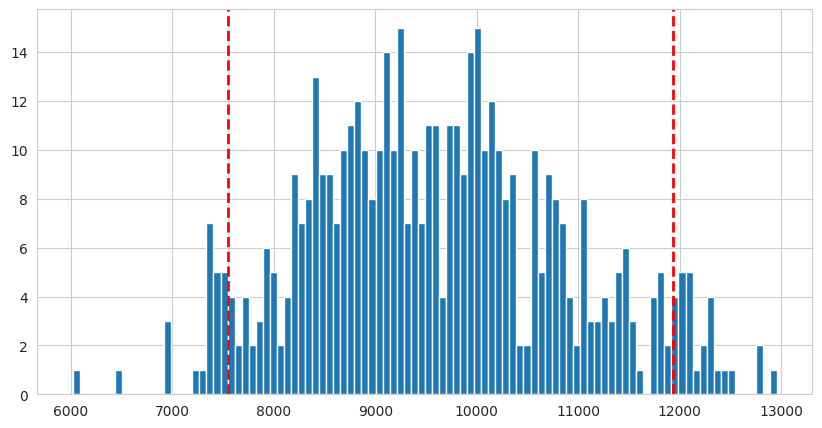

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(last_prices, bins=100)
plt.axvline(np.percentile(last_prices,5), color='r', linestyle='dashed', linewidth=2)
plt.axvline(np.percentile(last_prices,95), color='r', linestyle='dashed', linewidth=2)
plt.show()

### 2. **전체 종목에 대한 Simulation**

In [ ]:
stock_codes = []
final_returns = []

# 전체 종목에 대해 진행
for i in tqdm(df['StockCode'].unique(), desc="Simulating"):
  single_stock_df = df[df['StockCode']== i]
  # 각 종목에 대해, 변화율에 대한 'mu와 sigma'를 구하는 식
  returns = np.log(1 + single_stock_df['Close'].pct_change())
  mu, sigma = returns.mean(), returns.std()
  # initial : 예측 시작 시점
  initial = single_stock_df['Close'].iloc[-1]

  last_prices = []

  # 1000가지의 경우의 수를 랜덤하게 생성
  for t in range(1000) :
    # 경우의 수는 각 종목의 mu와 sigma 분포를 따르도록 생성
    sim_rets = np.random.normal(mu, sigma, 15)
    sim_prices = initial * (sim_rets +1).cumprod()
    last_prices.append(sim_prices[-1])

  # 마지막 15일 뒤 금액을 평균, 중간값, 최빈값 중 하나를 골라 설정
  # final_price = np.mean(last_prices)
  final_price = np.mean(last_prices)
  final_return = (final_price - initial)/initial

  # df로 저장하기 위해 list에 넣기
  stock_codes.append(i)
  final_returns.append(final_return)

result_df = pd.DataFrame({'StockCode': stock_codes, 'Final_return': final_returns})


Simulating:   0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
results_df = result_df.copy()

### 3. **순위 매겨서 제출하기**

In [ ]:
# 종목코드에 A 붙이기
results_df['StockCode'] = 'A' + results_df['StockCode'].astype(str)
# 순위 매겨주기
results_df['순위'] = results_df['Final_return'].rank(method='first', ascending=False).astype('int')
results_df = results_df.rename(columns={'StockCode': '종목코드'})
results_df

,종목코드,Final_return,순위
0,A060310,0.003566,323
1,A095570,-0.008683,886
2,A006840,-0.020257,1553
3,A054620,-0.009258,923
4,A265520,-0.009469,934
...,...,...,...
1995,A189980,-0.005709,708
1996,A000540,-0.011504,1071
1997,A003280,0.027693,74
1998,A037440,-0.001427,508


In [ ]:
# 제출 csv 불러오기
sample_submission = pd.read_csv('/content/drive/MyDrive/open/sample_submission.csv')
sample_submission

,종목코드,순위
0,A000020,1
1,A000040,2
2,A000050,3
3,A000070,4
4,A000080,5
...,...,...
1995,A375500,1996
1996,A378850,1997
1997,A383220,1998
1998,A383310,1999


In [ ]:
# 제출 csv format에 종목코드를 기반으로 mapping해주기
baseline_submission = sample_submission[['종목코드']].merge(results_df[['종목코드', '순위']], on='종목코드', how='left')
baseline_submission

,종목코드,순위
0,A000020,1179
1,A000040,1465
2,A000050,1084
3,A000070,1141
4,A000080,1440
...,...,...
1995,A375500,1935
1996,A378850,1037
1997,A383220,1944
1998,A383310,1642


In [ ]:
baseline_submission.to_csv('Monte_Carlo_short_submission2.csv', index=False)